# 📗 Pre-Workshop Notebook 2: Working with Larger Research Datasets
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [1]:
# PROFILE SYNC
student_name = "Dr. Evie A. Malaia"
institution = "University of Alabama"
active_notebook = "Notebook 02 — Larger Datasets and Simultaneous Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Dr. Evie A. Malaia (University of Alabama)
Current notebook: Notebook 02 — Larger Datasets and Simultaneous Processing


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with larger datasets, your main challenge is managing how much data your analysis can handle at once. AI tools are excellent at writing individual calculations, but they sometimes ignore the fact that loading too much data at once can slow your computer down or cause it to run out of working memory.

When using the **Ask → Build → Document** cycle in this notebook, pay attention to how much memory your analysis is using, and ask the AI to explain any steps that involve loading large amounts of data.

---
## 🧠 Part A: Handling Data from Many Participants at Once
### Topic: Group-Level Datasets and Downloading Data Reliably

This section explores what changes when your analysis needs to handle data from an entire group of research participants rather than just one person at a time.

### 🧭 Activity A.1 — Building a Group Dataset

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data analyst helping a researcher scale up from a single participant to a full study. Write a Python script using NumPy that simulates loading and combining data from 50 research participants. The script should:
> 1. For each of 50 participants, generate a data array representing 64 recording channels measured across 1000 time points in 3 experimental conditions.
> 2. Combine all 50 individual participant arrays into a single group-level dataset efficiently, without creating unnecessary copies of the data.
> 3. Report the size and shape of the combined dataset and calculate how much working memory it uses — then estimate how large the dataset would become if the study included 500 participants instead.
> Add plain-language comments explaining what each step does and what the numbers represent."

In [2]:
# 💻 Activity A.1 — Paste your AI-generated Group Dataset code here:
import numpy as np


# ============================================================
# Group-level neuroscience dataset simulation
# ============================================================
#
# We will simulate a study with:
#   50 participants
#   64 recording channels per participant
#   1,000 time points per channel
#   3 experimental conditions
#
# The resulting dataset will have the shape:
#
#   (participants, conditions, channels, time points)
#   (50, 3, 64, 1000)
#
# This is a toy example. Real neuroscience datasets often have
# additional dimensions such as trials, sessions, electrode
# locations, frequencies, or behavioral measurements.
# ============================================================


# ------------------------------------------------------------
# Study parameters
# ------------------------------------------------------------

n_participants = 50
n_channels = 64
n_timepoints = 1000
n_conditions = 3

# float32 uses 4 bytes per number.
#
# Using float32 instead of float64 is often useful for large
# scientific datasets when the extra numerical precision of
# float64 is not necessary.
dtype = np.float32


# ------------------------------------------------------------
# Function to generate one participant
# ------------------------------------------------------------

def generate_participant_data(
    participant_id,
    n_conditions,
    n_channels,
    n_timepoints
):
    """
    Generate simulated recordings for one participant.

    The returned array has the shape:

        (conditions, channels, time points)

    For example:
        (3, 64, 1000)

    Each number represents a simulated recording measurement.
    """

    # A separate random generator gives each participant a
    # slightly different pattern of measurements.
    rng = np.random.default_rng(1000 + participant_id)

    # Start with normally distributed background activity.
    # The numbers have arbitrary units because this is a simulation.
    data = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(
            n_conditions,
            n_channels,
            n_timepoints
        )
    ).astype(dtype)

    # Add a small participant-specific signal difference.
    # This illustrates that people can have different baseline
    # neural responses even when they perform the same task.
    participant_effect = participant_id * 0.01

    data += participant_effect

    return data


# ------------------------------------------------------------
# Stage 1: Generate the 50 participant datasets
# ------------------------------------------------------------

print("=" * 65)
print("SIMULATING A 50-PARTICIPANT NEUROSCIENCE STUDY")
print("=" * 65)

print("\nGenerating individual participant datasets...")

participant_data = []

for participant_id in range(n_participants):

    data = generate_participant_data(
        participant_id,
        n_conditions,
        n_channels,
        n_timepoints
    )

    participant_data.append(data)

    print(
        f"  Participant {participant_id + 1:2d}: "
        f"shape = {data.shape}, "
        f"memory = {data.nbytes / (1024 ** 2):.2f} MB"
    )


# ------------------------------------------------------------
# Stage 2: Combine participants into one group dataset
# ------------------------------------------------------------

print("\nCombining participants into one group dataset...")

# np.stack creates ONE final contiguous NumPy array containing
# all participants.
#
# The resulting shape is:
#
#   (50 participants,
#    3 conditions,
#    64 channels,
#    1000 time points)
#
# The participant arrays are not repeatedly concatenated one at
# a time. Repeated np.concatenate calls can repeatedly allocate
# and copy growing arrays, which becomes inefficient for large
# studies.
#
# Instead, we create the final group array once.
group_data = np.stack(
    participant_data,
    axis=0
)


# ------------------------------------------------------------
# Report the combined dataset
# ------------------------------------------------------------

print("\nGroup-level dataset:")
print(f"  Shape: {group_data.shape}")
print(f"  Data type: {group_data.dtype}")
print(f"  Number of values: {group_data.size:,}")

# nbytes tells us exactly how many bytes NumPy allocated for
# the numerical contents of this array.
group_memory_bytes = group_data.nbytes

print(
    f"  Working memory used by array: "
    f"{group_memory_bytes / (1024 ** 2):.2f} MB"
)

print(
    f"  Working memory used by array: "
    f"{group_memory_bytes / (1024 ** 3):.3f} GB"
)


# ------------------------------------------------------------
# Explain the memory calculation
# ------------------------------------------------------------

print("\nWhy does it use this much memory?")

print(
    f"  {n_participants} participants × "
    f"{n_conditions} conditions × "
    f"{n_channels} channels × "
    f"{n_timepoints:,} time points"
)

print(
    f"  = {group_data.size:,} individual measurements"
)

print(
    f"  Each float32 measurement uses "
    f"{np.dtype(dtype).itemsize} bytes"
)

print(
    f"  Total = {group_data.size:,} × "
    f"{np.dtype(dtype).itemsize} bytes"
)


# ------------------------------------------------------------
# Stage 3: Estimate the size of a 500-participant study
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SCALING THE STUDY TO 500 PARTICIPANTS")
print("=" * 65)

n_future_participants = 500

# The memory requirement scales approximately linearly with the
# number of participants when all other dimensions remain the same.
#
# 500 participants is 10 times as many as 50 participants,
# so the dataset will also require approximately 10 times
# as much memory.
estimated_future_bytes = (
    n_future_participants
    * n_conditions
    * n_channels
    * n_timepoints
    * np.dtype(dtype).itemsize
)

estimated_future_mb = (
    estimated_future_bytes / (1024 ** 2)
)

estimated_future_gb = (
    estimated_future_bytes / (1024 ** 3)
)

print(
    f"\nEstimated shape with {n_future_participants} participants:"
)

print(
    f"  ({n_future_participants}, "
    f"{n_conditions}, "
    f"{n_channels}, "
    f"{n_timepoints})"
)

print(
    f"\nEstimated numerical data size:"
    f"\n  {estimated_future_mb:.2f} MB"
    f"\n  {estimated_future_gb:.3f} GB"
)


# ------------------------------------------------------------
# Final comparison
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)

print(
    f"\n50 participants:"
    f"\n  {group_memory_bytes / (1024 ** 2):.2f} MB"
)

print(
    f"\n500 participants:"
    f"\n  {estimated_future_mb:.2f} MB"
)

print(
    f"\nScaling factor:"
    f"\n  {n_future_participants / n_participants:.0f}x more participants"
)

print(
    "\nThe important computational lesson is that group studies "
    "can become large very quickly."
)

print(
    "If you increase the number of participants, channels, "
    "time points, or conditions, the memory requirement grows "
    "multiplicatively."
)

print(
    "\nFor larger real-world studies, researchers may therefore "
    "process participants in batches, use memory-mapped files, "
    "or store data in formats designed for large datasets "
    "instead of loading everything into RAM at once."
)


# ------------------------------------------------------------
# Optional cleanup
# ------------------------------------------------------------

# Delete the individual references after the group array has
# been created. This allows Python to reclaim those separate
# participant arrays when no longer needed.
#
# IMPORTANT:
# group_data is independent of the list after np.stack(), so
# deleting the list does not delete the group dataset.
del participant_data

print("\nIndividual participant arrays have been released.")
print(
    "The combined group_data array remains available for analysis."
)


SIMULATING A 50-PARTICIPANT NEUROSCIENCE STUDY

Generating individual participant datasets...
  Participant  1: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  2: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  3: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  4: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  5: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  6: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  7: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  8: shape = (3, 64, 1000), memory = 0.73 MB
  Participant  9: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 10: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 11: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 12: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 13: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 14: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 15: shape = (3, 64, 1000), memory = 0.73 MB
  Participant 16: shape = (3, 64, 10

### 🧭 Activity A.2 — Downloading Data Reliably

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research workflow instructor. Internet connections sometimes drop or get temporarily blocked when downloading large research datasets. Write a Python script that simulates a reliable data download system. The script should:
> 1. Simulate a download function that requests 10 chunks of data from a research repository, one at a time.
> 2. Randomly cause some of the download attempts to fail, to simulate real network interruptions.
> 3. Automatically retry failed downloads, waiting a little longer between each attempt (e.g., wait 1 second after the first failure, 2 seconds after the second, 4 seconds after the third) rather than giving up immediately.
> 4. Print a clear log showing which downloads succeeded, which failed, and how many retries were needed.
> Use plain-language comments explaining why this retry approach is better than simply stopping when an error occurs."

In [3]:
# 💻 Activity A.2 — Paste your AI-generated Reliable Download code here:
import random
import time


# ============================================================
# Reliable research-data download simulation
# ============================================================
#
# Imagine that a research dataset is stored in a repository.
# Instead of downloading the whole dataset at once, we download
# it as 10 separate chunks.
#
# Real network connections can fail temporarily because of:
#   - Wi-Fi interruptions
#   - overloaded servers
#   - temporary internet outages
#   - connection timeouts
#
# A robust research workflow should not throw away everything
# just because one temporary connection fails.
#
# This example uses "exponential backoff":
#
#   1st failure -> wait 1 second
#   2nd failure -> wait 2 seconds
#   3rd failure -> wait 4 seconds
#   4th failure -> wait 8 seconds
#
# Waiting longer between attempts reduces the pressure on a
# temporarily busy server and gives the network time to recover.
# ============================================================


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

NUMBER_OF_CHUNKS = 10

# Maximum number of times we will retry a failed chunk.
# The initial attempt does NOT count as a retry.
MAX_RETRIES = 4

# Probability that a simulated network request fails.
# 0.30 means each attempt has a 30% chance of failure.
FAILURE_PROBABILITY = 0.30

# Set this to True if you want to actually wait during the
# demonstration.
#
# Set it to False to run the example almost instantly.
REAL_WAIT = True

# A fixed seed makes the demonstration reproducible.
# Remove or change this number if you want a different pattern
# of network failures each time.
random.seed(42)


# ------------------------------------------------------------
# Simulated download function
# ------------------------------------------------------------

def download_chunk(chunk_number):
    """
    Pretend to download one chunk from a research repository.

    In a real workflow, this function might use requests,
    urllib, an API client, or another network library.

    Here we randomly decide whether the connection succeeds.
    """

    print(
        f"      Requesting chunk {chunk_number}..."
    )

    # Randomly simulate a network interruption.
    if random.random() < FAILURE_PROBABILITY:

        # Raising an exception is similar to what a real network
        # library might do when a request fails.
        raise ConnectionError(
            "Simulated network interruption"
        )

    # If the simulated request succeeds, return some placeholder
    # data. Real code would return the bytes or data received
    # from the research repository.
    return f"data_for_chunk_{chunk_number}"


# ------------------------------------------------------------
# Retry logic
# ------------------------------------------------------------

def download_with_retries(chunk_number):
    """
    Download one chunk, retrying temporary failures.

    Returns
    -------
    data, retries
        The downloaded data and the number of retries required.

    Why retry?
    ----------
    A temporary network failure does not necessarily mean that
    the dataset is unavailable. Retrying allows the workflow to
    recover automatically instead of forcing the researcher to
    restart the entire download manually.
    """

    retries = 0

    while True:

        try:
            # Try to download the chunk.
            data = download_chunk(chunk_number)

            # If we get here, the download succeeded.
            return data, retries

        except ConnectionError as error:

            # We have experienced another failed attempt.
            retries += 1

            print(
                f"      FAILED: {error}"
            )

            # If we've used all our allowed retries, stop trying
            # this particular chunk.
            if retries > MAX_RETRIES:

                print(
                    f"      Giving up on chunk {chunk_number} "
                    f"after {MAX_RETRIES} retries."
                )

                return None, retries - 1

            # Exponential backoff:
            #
            # retry 1 -> 1 second
            # retry 2 -> 2 seconds
            # retry 3 -> 4 seconds
            # retry 4 -> 8 seconds
            wait_seconds = 2 ** (retries - 1)

            print(
                f"      Retry {retries}/{MAX_RETRIES}: "
                f"waiting {wait_seconds} second(s)..."
            )

            if REAL_WAIT:
                time.sleep(wait_seconds)


# ------------------------------------------------------------
# Main download workflow
# ------------------------------------------------------------

def main():

    print("=" * 65)
    print("RELIABLE RESEARCH-DATA DOWNLOAD SIMULATION")
    print("=" * 65)

    print(
        f"\nRepository contains {NUMBER_OF_CHUNKS} chunks."
    )

    print(
        f"Simulated failure probability: "
        f"{FAILURE_PROBABILITY * 100:.0f}%"
    )

    print(
        f"Maximum retries per chunk: "
        f"{MAX_RETRIES}"
    )

    print()

    # Store successfully downloaded chunks here.
    downloaded_chunks = []

    # Keep track of how many retries were required.
    retry_counts = {}

    # Keep track of chunks that ultimately failed.
    failed_chunks = []

    # --------------------------------------------------------
    # Download chunks one at a time
    # --------------------------------------------------------

    for chunk_number in range(1, NUMBER_OF_CHUNKS + 1):

        print(
            f"\n--- Chunk {chunk_number}/{NUMBER_OF_CHUNKS} ---"
        )

        data, retries = download_with_retries(
            chunk_number
        )

        retry_counts[chunk_number] = retries

        if data is not None:

            downloaded_chunks.append(data)

            if retries == 0:
                print(
                    f"      SUCCESS: chunk {chunk_number} "
                    f"succeeded on the first attempt."
                )
            else:
                print(
                    f"      SUCCESS: chunk {chunk_number} "
                    f"succeeded after {retries} retry/retries."
                )

        else:

            failed_chunks.append(chunk_number)

            print(
                f"      ERROR: chunk {chunk_number} "
                f"could not be downloaded."
            )


    # --------------------------------------------------------
    # Final report
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("DOWNLOAD SUMMARY")
    print("=" * 65)

    successful = len(downloaded_chunks)
    failed = len(failed_chunks)

    total_retries = sum(
        retry_counts.values()
    )

    print(
        f"\nChunks requested:       {NUMBER_OF_CHUNKS}"
    )

    print(
        f"Chunks successfully downloaded: {successful}"
    )

    print(
        f"Chunks that ultimately failed:  {failed}"
    )

    print(
        f"Total retries performed:        {total_retries}"
    )


    # Show the retry history for every chunk.
    print("\nRetry history:")

    for chunk_number in range(
        1,
        NUMBER_OF_CHUNKS + 1
    ):

        status = (
            "SUCCESS"
            if chunk_number not in failed_chunks
            else "FAILED"
        )

        print(
            f"  Chunk {chunk_number:2d}: "
            f"{status:7s} | "
            f"retries = {retry_counts[chunk_number]}"
        )


    # --------------------------------------------------------
    # Explain why retrying is useful
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("WHY RETRIES MATTER")
    print("=" * 65)

    print(
        """
A temporary network failure does not necessarily mean that
the research dataset is unavailable.

Without retries:
    One failed request could stop the entire workflow.

With retries:
    The program waits, tries again, and often recovers
    automatically when the network becomes available.

Exponential backoff is especially useful because it avoids
immediately sending many requests to a server that may already
be overloaded.

For large research datasets, this can save substantial time:
the researcher does not have to manually restart a long
download every time there is a brief connection problem.
"""
    )

    if failed_chunks:

        print(
            "The following chunks still failed after all retries:"
        )

        print(
            f"  {failed_chunks}"
        )

        print(
            "\nA production system could record these chunk IDs "
            "in a log and resume them later."
        )

    else:

        print(
            "All chunks were downloaded successfully!"
        )


# ------------------------------------------------------------
# Start the demonstration
# ------------------------------------------------------------

if __name__ == "__main__":
    main()


RELIABLE RESEARCH-DATA DOWNLOAD SIMULATION

Repository contains 10 chunks.
Simulated failure probability: 30%
Maximum retries per chunk: 4


--- Chunk 1/10 ---
      Requesting chunk 1...
      SUCCESS: chunk 1 succeeded on the first attempt.

--- Chunk 2/10 ---
      Requesting chunk 2...
      FAILED: Simulated network interruption
      Retry 1/4: waiting 1 second(s)...
      Requesting chunk 2...
      FAILED: Simulated network interruption
      Retry 2/4: waiting 2 second(s)...
      Requesting chunk 2...
      FAILED: Simulated network interruption
      Retry 3/4: waiting 4 second(s)...
      Requesting chunk 2...
      SUCCESS: chunk 2 succeeded after 3 retry/retries.

--- Chunk 3/10 ---
      Requesting chunk 3...
      SUCCESS: chunk 3 succeeded on the first attempt.

--- Chunk 4/10 ---
      Requesting chunk 4...
      SUCCESS: chunk 4 succeeded on the first attempt.

--- Chunk 5/10 ---
      Requesting chunk 5...
      FAILED: Simulated network interruption
      Retry 1/4

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the dataset sizes from Activity A.1, how does memory usage change as the number of participants grows? What practical limits does this create for a research study? - As the number of participants grows, memory usage increases linearly when the number of channels, time points, and conditions stays the same. his creates practical limits because a researcher may eventually have more data than can comfortably fit in RAM, so need to use smaller batches.
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 11, 14, 16, and 43** from your Reference Guide. Describe why a reliable retry system for downloads matters for reproducibility in large studies. -  A reliable retry system makes the workflow more robust, automated, and repeatable, which is especially important as studies grow.

---

## 💻 Part B: Making Analyses Run Faster
### Topic: Running Multiple Analyses at the Same Time and Choosing Efficient Data Formats

This section explores two practical strategies for making research workflows faster when working with large datasets.

### 🧭 Activity B.1 — Running Analyses One-at-a-Time vs. All at Once

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computing performance instructor. Write a Python script that demonstrates the difference between running a data analysis one participant at a time versus running many participants simultaneously using multiple processor cores. The script should:
> 1. Define a data analysis function that performs a moderately demanding calculation — such as computing a rolling average across a large array.
> 2. Apply this function to 10 separate datasets one at a time, measuring how long the whole process takes.
> 3. Apply the same function to the same 10 datasets simultaneously using Python's multiprocessing library, distributing the work across available processor cores, and measuring how long that takes.
> 4. Display a bar chart comparing the two approaches and calculate the speedup factor.
> Use plain-language comments explaining what is happening and why one approach is faster."

SERIAL VS. MULTI-CORE DATA ANALYSIS

CPU cores detected: 2
Creating 10 datasets with 2,000,000 values each...

Running serial analysis...
  Processing participant 1/10
  Processing participant 2/10
  Processing participant 3/10
  Processing participant 4/10
  Processing participant 5/10
  Processing participant 6/10
  Processing participant 7/10
  Processing participant 8/10
  Processing participant 9/10
  Processing participant 10/10

Running parallel analysis...

Do both approaches produce the same results? True

PERFORMANCE SUMMARY

Serial time:   0.050 seconds
Parallel time: 0.651 seconds
Speedup:       0.08x

The parallel version was not faster in this run.
This can happen when the calculation is too small to overcome the overhead of creating processes and moving data between them.
Larger datasets or more computationally demanding analyses usually make parallel processing more useful.


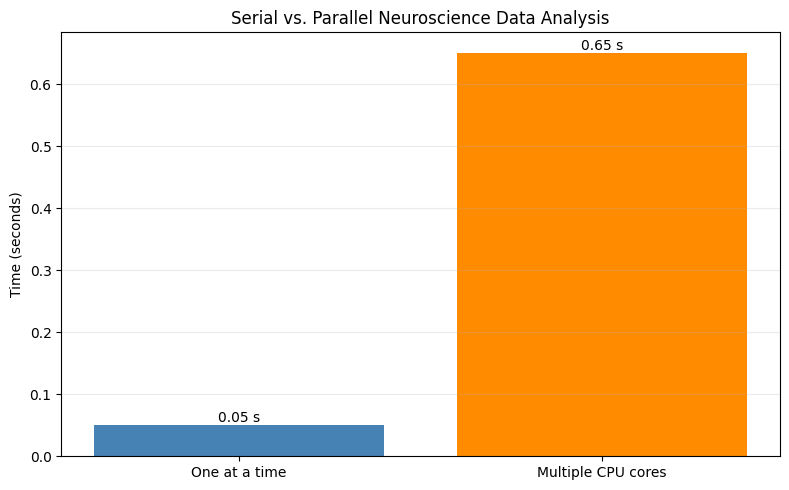


Figure saved as: serial_vs_parallel.png


In [4]:
# 💻 Activity B.1 — Paste your AI-generated Simultaneous Processing code here:
import multiprocessing as mp
import time

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Multiprocessing performance demonstration
# ============================================================
#
# We compare two approaches:
#
# 1. SERIAL PROCESSING
#    Analyze participant 1, then participant 2, then participant 3,
#    and so on.
#
# 2. PARALLEL PROCESSING
#    Give different participants to different CPU processes so
#    several analyses can happen at approximately the same time.
#
# In a neuroscience study, each dataset might represent one
# participant's neural recording.
# ============================================================


# ------------------------------------------------------------
# Study parameters
# ------------------------------------------------------------

N_PARTICIPANTS = 10

# A large array represents a reasonably substantial recording.
# Increasing this number makes the calculation more demanding,
# but also makes the demonstration take longer.
N_VALUES = 2_000_000

# Width of the rolling-average window.
WINDOW = 5


# ------------------------------------------------------------
# Create simulated participant datasets
# ------------------------------------------------------------

def create_datasets():
    """
    Generate 10 independent datasets.

    Each dataset contains 2 million measurements.
    """

    print(
        f"Creating {N_PARTICIPANTS} datasets "
        f"with {N_VALUES:,} values each..."
    )

    rng = np.random.default_rng(42)

    datasets = [
        rng.normal(
            loc=0.0,
            scale=1.0,
            size=N_VALUES
        ).astype(np.float64)
        for _ in range(N_PARTICIPANTS)
    ]

    return datasets


# ------------------------------------------------------------
# Define the analysis performed on ONE participant
# ------------------------------------------------------------

def analyze_participant(data):
    """
    Calculate a rolling average for one participant.

    A rolling average looks at a small window of neighboring
    measurements and calculates their average.

    For example, with a window of 5:

        [1, 2, 3, 4, 5] -> average = 3

    This is a simplified example of the type of numerical
    processing that might be performed on experimental data.

    The function returns a single summary number so that both
    the serial and parallel approaches perform exactly the
    same analysis.
    """

    # NumPy's convolution performs the rolling calculation
    # efficiently in compiled numerical code.
    kernel = np.ones(WINDOW) / WINDOW

    rolling_average = np.convolve(
        data,
        kernel,
        mode="valid"
    )

    # Return a summary statistic from the processed data.
    # This forces the calculation to produce a meaningful result.
    result = np.mean(rolling_average)

    return result


# ------------------------------------------------------------
# SERIAL PROCESSING
# ------------------------------------------------------------

def run_serial(datasets):
    """
    Analyze participants one after another.

    Only one participant is being processed by Python at a time.
    """

    print("\nRunning serial analysis...")

    results = []

    start = time.perf_counter()

    for participant_number, data in enumerate(
        datasets,
        start=1
    ):

        print(
            f"  Processing participant "
            f"{participant_number}/{len(datasets)}"
        )

        result = analyze_participant(data)
        results.append(result)

    elapsed = time.perf_counter() - start

    return results, elapsed


# ------------------------------------------------------------
# PARALLEL PROCESSING
# ------------------------------------------------------------

def run_parallel(datasets):
    """
    Analyze participants using multiple CPU processes.

    Each worker process receives one participant's dataset and
    runs analyze_participant() independently.

    The operating system can schedule these processes on
    different processor cores.
    """

    print("\nRunning parallel analysis...")

    start = time.perf_counter()

    # mp.Pool creates a group of worker processes.
    #
    # By default, processes are created for the available CPU
    # cores. We report the number so the researcher can see how
    # much parallel hardware is being used.
    with mp.Pool(
        processes=mp.cpu_count()
    ) as pool:

        results = pool.map(
            analyze_participant,
            datasets
        )

    elapsed = time.perf_counter() - start

    return results, elapsed


# ------------------------------------------------------------
# Plot the performance comparison
# ------------------------------------------------------------

def plot_results(serial_time, parallel_time):
    """
    Create a bar chart comparing the two approaches.
    """

    methods = [
        "One at a time",
        "Multiple CPU cores"
    ]

    times = [
        serial_time,
        parallel_time
    ]

    colors = [
        "steelblue",
        "darkorange"
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        methods,
        times,
        color=colors
    )

    ax.set_ylabel("Time (seconds)")
    ax.set_title(
        "Serial vs. Parallel Neuroscience Data Analysis"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    # Put the measured time above each bar.
    for bar, value in zip(bars, times):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f} s",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    plt.savefig(
        "serial_vs_parallel.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# Main program
# ------------------------------------------------------------

def main():

    print("=" * 65)
    print("SERIAL VS. MULTI-CORE DATA ANALYSIS")
    print("=" * 65)

    print(
        f"\nCPU cores detected: {mp.cpu_count()}"
    )

    # Generate the same datasets that will be used by both
    # approaches. This makes the timing comparison fair.
    datasets = create_datasets()

    # --------------------------------------------------------
    # Analyze participants one at a time
    # --------------------------------------------------------

    serial_results, serial_time = run_serial(
        datasets
    )

    # --------------------------------------------------------
    # Analyze the same participants in parallel
    # --------------------------------------------------------

    parallel_results, parallel_time = run_parallel(
        datasets
    )

    # --------------------------------------------------------
    # Verify that both approaches produced the same results
    # --------------------------------------------------------

    results_match = np.allclose(
        serial_results,
        parallel_results
    )

    print(
        f"\nDo both approaches produce the same results? "
        f"{results_match}"
    )

    # --------------------------------------------------------
    # Calculate speedup
    # --------------------------------------------------------

    # Speedup tells us how many times faster the parallel
    # approach was compared with the serial approach.
    #
    # Example:
    #   serial = 20 seconds
    #   parallel = 5 seconds
    #
    #   speedup = 20 / 5 = 4x
    speedup = serial_time / parallel_time

    print("\n" + "=" * 65)
    print("PERFORMANCE SUMMARY")
    print("=" * 65)

    print(
        f"\nSerial time:   {serial_time:.3f} seconds"
    )

    print(
        f"Parallel time: {parallel_time:.3f} seconds"
    )

    print(
        f"Speedup:       {speedup:.2f}x"
    )

    # --------------------------------------------------------
    # Explain the result
    # --------------------------------------------------------

    if speedup > 1:

        print(
            f"\nThe multi-process approach was approximately "
            f"{speedup:.2f} times faster."
        )

        print(
            "Different participant analyses could run on "
            "different CPU cores, reducing the total elapsed time."
        )

    else:

        print(
            "\nThe parallel version was not faster in this run."
        )

        print(
            "This can happen when the calculation is too small "
            "to overcome the overhead of creating processes and "
            "moving data between them."
        )

        print(
            "Larger datasets or more computationally demanding "
            "analyses usually make parallel processing more useful."
        )

    # --------------------------------------------------------
    # Create performance chart
    # --------------------------------------------------------

    plot_results(
        serial_time,
        parallel_time
    )

    print(
        "\nFigure saved as: serial_vs_parallel.png"
    )


# ------------------------------------------------------------
# IMPORTANT FOR MULTIPROCESSING
# ------------------------------------------------------------
#
# The main() call must be protected by this condition.
#
# This is especially important on Windows, where Python starts
# new processes by importing the program again. Without this
# protection, the program could accidentally start creating
# more worker processes recursively.
# ------------------------------------------------------------

if __name__ == "__main__":
    main()


### 🧭 Activity B.2 — Saving Data in Efficient Formats

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a data management instructor. Write a Python script that demonstrates the difference between saving research data as a plain text file versus a more efficient binary format. The script should:
> 1. Generate a simulated dataset representing measurements from 100,000 time points across multiple recording channels.
> 2. Save this dataset in two formats: a plain text CSV file (like you would open in a spreadsheet) and an optimized binary file (such as NumPy's .npy format or HDF5).
> 3. Compare the file sizes on disk for both formats.
> 4. Measure and compare how long it takes to load each file back into memory for analysis.
> Use plain-language comments explaining the trade-offs between the two formats and when you would choose each one."

In [5]:
# 💻 Activity B.2 — Paste your AI-generated Data Format Comparison code here:
import csv
import os
import time

import numpy as np


# ============================================================
# Text CSV vs. binary NumPy storage
# ============================================================
#
# We simulate a recording with:
#
#   100,000 time points
#   8 recording channels
#
# That gives us 800,000 individual measurements.
#
# CSV:
#   - Human-readable
#   - Easy to open in Excel/spreadsheets
#   - Easy to exchange with other software
#   - Usually larger and slower to load
#
# NumPy .npy:
#   - Binary format designed for NumPy arrays
#   - Preserves the numerical data type and array shape
#   - Usually much smaller and faster to load
#   - Less convenient for a person to inspect manually
#
# The exact size and speed difference depends on the computer,
# disk, operating system, and data itself.
# ============================================================


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

N_TIMEPOINTS = 100_000
N_CHANNELS = 8

CSV_FILENAME = "research_data.csv"
NPY_FILENAME = "research_data.npy"


# ------------------------------------------------------------
# 1. Generate simulated research data
# ------------------------------------------------------------

print("=" * 65)
print("GENERATING SIMULATED RESEARCH DATA")
print("=" * 65)

print(
    f"\nCreating {N_TIMEPOINTS:,} time points "
    f"across {N_CHANNELS} recording channels..."
)

# Use float32 because it requires only 4 bytes per measurement.
# This is often sufficient for simulated sensor data and keeps
# the demonstration reasonably small.
rng = np.random.default_rng(42)

data = rng.normal(
    loc=0.0,
    scale=1.0,
    size=(N_TIMEPOINTS, N_CHANNELS)
).astype(np.float32)

print(f"Dataset shape: {data.shape}")
print(f"Data type:     {data.dtype}")
print(
    f"Measurements:  {data.size:,}"
)
print(
    f"Raw numerical data: "
    f"{data.nbytes / (1024 ** 2):.2f} MB"
)


# ------------------------------------------------------------
# 2. Save the data as a CSV text file
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SAVING AS PLAIN-TEXT CSV")
print("=" * 65)

print("\nWriting CSV file...")

start = time.perf_counter()

# newline="" prevents extra blank lines on some operating systems.
with open(
    CSV_FILENAME,
    "w",
    newline=""
) as file:

    writer = csv.writer(file)

    # Write column names so that a researcher opening the file
    # in a spreadsheet can tell which channel is which.
    writer.writerow(
        [
            f"channel_{i + 1}"
            for i in range(N_CHANNELS)
        ]
    )

    # Write every measurement as text.
    #
    # Text is convenient for humans, but converting numerical
    # values into characters adds storage overhead.
    for row in data:
        writer.writerow(row)

csv_write_time = time.perf_counter() - start

csv_size = os.path.getsize(CSV_FILENAME)

print(
    f"CSV file size:  "
    f"{csv_size / (1024 ** 2):.2f} MB"
)

print(
    f"CSV write time: "
    f"{csv_write_time:.3f} seconds"
)


# ------------------------------------------------------------
# 3. Save the same data as a NumPy binary file
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SAVING AS NUMPY BINARY (.NPY)")
print("=" * 65)

print("\nWriting NumPy binary file...")

start = time.perf_counter()

# np.save stores the numerical values in binary form.
#
# Unlike CSV, it also records information needed by NumPy to
# reconstruct the array, including its shape and data type.
np.save(
    NPY_FILENAME,
    data
)

npy_write_time = time.perf_counter() - start

npy_size = os.path.getsize(NPY_FILENAME)

print(
    f"NPY file size:   "
    f"{npy_size / (1024 ** 2):.2f} MB"
)

print(
    f"NPY write time:  "
    f"{npy_write_time:.3f} seconds"
)


# ------------------------------------------------------------
# 4. Load the CSV file back into memory
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("LOADING CSV FILE")
print("=" * 65)

start = time.perf_counter()

# np.loadtxt reads the text and converts the characters back
# into numerical values.
#
# skiprows=1 ignores the column-name header.
csv_loaded = np.loadtxt(
    CSV_FILENAME,
    delimiter=",",
    skiprows=1,
    dtype=np.float32
)

csv_load_time = time.perf_counter() - start

print(
    f"Loaded CSV shape: {csv_loaded.shape}"
)

print(
    f"CSV load time:    "
    f"{csv_load_time:.3f} seconds"
)


# ------------------------------------------------------------
# 5. Load the NumPy binary file back into memory
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("LOADING NUMPY BINARY FILE")
print("=" * 65)

start = time.perf_counter()

# np.load can reconstruct the array directly from the binary
# representation without parsing thousands of text characters.
npy_loaded = np.load(
    NPY_FILENAME
)

npy_load_time = time.perf_counter() - start

print(
    f"Loaded NPY shape: {npy_loaded.shape}"
)

print(
    f"NPY load time:    "
    f"{npy_load_time:.3f} seconds"
)


# ------------------------------------------------------------
# 6. Verify that both files contain the same data
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("VERIFYING THE DATA")
print("=" * 65)

csv_matches_original = np.allclose(
    data,
    csv_loaded
)

npy_matches_original = np.array_equal(
    data,
    npy_loaded
)

print(
    f"CSV matches original: "
    f"{csv_matches_original}"
)

print(
    f"NPY matches original: "
    f"{npy_matches_original}"
)


# ------------------------------------------------------------
# 7. Compare disk sizes
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("DISK-SIZE COMPARISON")
print("=" * 65)

csv_size_mb = csv_size / (1024 ** 2)
npy_size_mb = npy_size / (1024 ** 2)

print(
    f"\nCSV: {csv_size_mb:.2f} MB"
)

print(
    f"NPY: {npy_size_mb:.2f} MB"
)

if npy_size > 0:
    size_ratio = csv_size / npy_size

    print(
        f"\nCSV is approximately "
        f"{size_ratio:.1f}x the size of the NPY file."
    )


# ------------------------------------------------------------
# 8. Compare loading speeds
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("LOADING-SPEED COMPARISON")
print("=" * 65)

print(
    f"\nCSV load time: "
    f"{csv_load_time:.3f} seconds"
)

print(
    f"NPY load time: "
    f"{npy_load_time:.3f} seconds"
)

if npy_load_time > 0:

    load_speed_ratio = (
        csv_load_time / npy_load_time
    )

    print(
        f"\nCSV loading took approximately "
        f"{load_speed_ratio:.1f}x as long as NPY."
    )


# ------------------------------------------------------------
# 9. Explain when each format is useful
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("WHAT DOES THIS MEAN FOR RESEARCH?")
print("=" * 65)

print(
    """
CSV is useful when:
  - Humans need to inspect the data.
  - You need to open the data in a spreadsheet.
  - You need a simple, widely supported exchange format.
  - You are sending a relatively small table to another researcher.

Binary formats such as NPY are useful when:
  - The same data will be analyzed repeatedly.
  - Loading speed matters.
  - Datasets are large.
  - You want to preserve NumPy's data type and array structure.
  - You want to reduce unnecessary disk usage.

A common research workflow is therefore to keep a convenient
text representation for sharing or inspection when appropriate,
while using a binary or specialized scientific format for the
main computational analysis.
"""
)


# ------------------------------------------------------------
# 10. Clean up the demonstration files
# ------------------------------------------------------------

# These files were created just for this demonstration.
# Delete them so the script does not leave large test files
# behind in the working directory.
os.remove(CSV_FILENAME)
os.remove(NPY_FILENAME)

print(
    "Temporary CSV and NPY files have been removed."
)


GENERATING SIMULATED RESEARCH DATA

Creating 100,000 time points across 8 recording channels...
Dataset shape: (100000, 8)
Data type:     float32
Measurements:  800,000
Raw numerical data: 3.05 MB

SAVING AS PLAIN-TEXT CSV

Writing CSV file...
CSV file size:  8.42 MB
CSV write time: 0.868 seconds

SAVING AS NUMPY BINARY (.NPY)

Writing NumPy binary file...
NPY file size:   3.05 MB
NPY write time:  0.004 seconds

LOADING CSV FILE
Loaded CSV shape: (100000, 8)
CSV load time:    0.136 seconds

LOADING NUMPY BINARY FILE
Loaded NPY shape: (100000, 8)
NPY load time:    0.002 seconds

VERIFYING THE DATA
CSV matches original: True
NPY matches original: True

DISK-SIZE COMPARISON

CSV: 8.42 MB
NPY: 3.05 MB

CSV is approximately 2.8x the size of the NPY file.

LOADING-SPEED COMPARISON

CSV load time: 0.136 seconds
NPY load time: 0.002 seconds

CSV loading took approximately 82.4x as long as NPY.

WHAT DOES THIS MEAN FOR RESEARCH?

CSV is useful when:
  - Humans need to inspect the data.
  - You 

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity B.1, how much faster was simultaneous processing compared to one-at-a-time? From Activity B.2, how much larger was the plain text file compared to the efficient format? - it wasn't. Data too small to illustrate distributed computing efficiency. B2 - plain text a lot larger, and slower to deal with.
* **Connecting to key concepts:** Activities B.1 and B.2 demonstrate **Concepts 27, 28, 42, and 43** from your Reference Guide. Explain in plain language when it makes sense to use simultaneous processing and when the overhead might not be worth it. - when there's large data set, and/or demanding computing steps, parallel computing is worth it. Once the data is inspected, keeping it in machine- rather than human-readable format always worth it.

---

## 📑 What Comes Next

Notebook 3 introduces signal processing — how to clean raw recordings, remove noise, and extract meaningful patterns from brain and behavioral data.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all five pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 11 — Continuous recordings vs. event markers | [ Enter Cell ID ] |
| Neuroscience | Concept 14 — Automated data download | [ Enter Cell ID ] |
| Neuroscience | Concept 16 — Downsampling | [ Enter Cell ID ] |
| Computing | Concept 27 — Processor cores | [ Enter Cell ID ] |
| Computing | Concept 28 — CPU vs. GPU | [ Enter Cell ID ] |
| Computing | Concept 43 — Simultaneous processing | [ Enter Cell ID ] |
